## Uninstall PaddlePaddle and PyTorch

In [10]:
!pip uninstall paddlepaddle paddlepaddle-gpu torch -y

Found existing installation: paddlepaddle-gpu 3.3.0
Uninstalling paddlepaddle-gpu-3.3.0:
  Successfully uninstalled paddlepaddle-gpu-3.3.0


## Install PaddlePaddle GPU (CUDA 12.6)

In [11]:
!pip install paddlepaddle-gpu==3.3.0 -i https://www.paddlepaddle.org.cn/packages/stable/cu126/


Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cu126/
  Using cached https://paddle-whl.bj.bcebos.com/stable/cu126/paddlepaddle-gpu/paddlepaddle_gpu-3.3.0-cp312-cp312-linux_x86_64.whl (1923.9 MB)


## Install PaddleOCR Library

In [12]:
!pip install paddleocr

## Verify PaddleOCR GPU Installation

In [13]:
from paddleocr import PaddleOCR
import paddle

print("CUDA:", paddle.is_compiled_with_cuda())
print("GPU count:", paddle.device.cuda.device_count())

# Initialization means everything is working
ocr = PaddleOCR(lang='en')
print("✅ PaddleOCR is ready to use with GPU!")

CUDA: True
GPU count: 1
✅ PaddleOCR is ready to use with GPU!


## Download Sample BMW Image for OCR Test

In [14]:
!wget https://cdn.bmwblog.com/wp-content/uploads/2015/12/2015-BMW-320d-xDrive-Touring-test-drive-67.jpg

--2026-07-17 13:38:19--  https://cdn.bmwblog.com/wp-content/uploads/2015/12/2015-BMW-320d-xDrive-Touring-test-drive-67.jpg
Resolving cdn.bmwblog.com (cdn.bmwblog.com)... 207.244.74.236
Connecting to cdn.bmwblog.com (cdn.bmwblog.com)|207.244.74.236|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 195252 (191K) [image/jpeg]
Saving to: ‘2015-BMW-320d-xDrive-Touring-test-drive-67.jpg.1’

2015-BMW-320d-xDriv 100%[===================>] 190.68K  1.02MB/s    in 0.2s    

2026-07-17 13:38:19 (1.02 MB/s) - ‘2015-BMW-320d-xDrive-Touring-test-drive-67.jpg.1’ saved [195252/195252]



## Initialize PaddleOCR and Run on Sample Image

In [1]:
# Suppress verbose logs from PaddleX, show only warnings and errors
import logging
logging.getLogger("paddlex").setLevel(logging.WARNING)
import matplotlib.pyplot as plt

from paddleocr import PaddleOCR

ocr = PaddleOCR(lang="en",
                device="gpu",
                use_textline_orientation=True) # Auto-detects and corrects rotated text lines (0° or 180°) for better accuracy.

img_path = r"/content/2015-BMW-320d-xDrive-Touring-test-drive-67.jpg"

result = ocr.predict(img_path)

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manu

## Show Sample Image with OCR Text Extraction

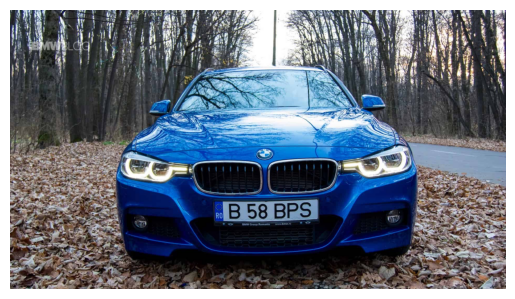

B 58 BPS (confidence: 97.13%)
RO (confidence: 99.60%)
BMW Group Romania (confidence: 95.99%)
www.bmw.ro (confidence: 99.70%)


In [2]:
plt.imshow(plt.imread(img_path))
plt.axis("off")
plt.show()

# Get text and confidence scores together
for text, score in zip(result[0]['rec_texts'], result[0]['rec_scores']):
    print(f"{text} (confidence: {score:.2%})")

## OCR on Cropped License Plate Image

In [4]:
# Suppress verbose logs from PaddleX, show only warnings and errors
import logging
logging.getLogger("paddlex").setLevel(logging.WARNING)
import matplotlib.pyplot as plt

from paddleocr import PaddleOCR

ocr = PaddleOCR(lang="en",
                device="gpu",
                use_textline_orientation=True) # Auto-detects and corrects rotated text lines (0° or 180°) for better accuracy.

img_path = r"/content/Screenshot 2026-07-17 144306.png"

result = ocr.predict(img_path)

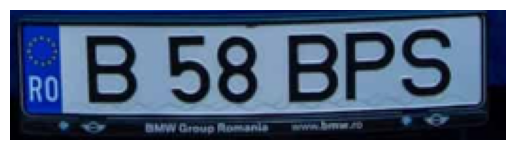

B 58 BPS (confidence: 99.86%)


In [5]:
plt.imshow(plt.imread(img_path))
plt.axis("off")
plt.show()

# Get text and confidence scores together
for text, score in zip(result[0]['rec_texts'], result[0]['rec_scores']):
    print(f"{text} (confidence: {score:.2%})")